In [ ]:
# import warnings
# warnings.filterwarnings("ignore")

In [169]:
import re
import string
import joblib
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from wordcloud import WordCloud

import nltk
from nltk.probability import FreqDist

import gensim
from gensim import corpora
from gensim.models import Phrases
from gensim.models.phrases import Phraser

In [223]:
import spacy
nlp = spacy.load("uk_core_news_sm")
import uk_core_news_sm
nlp = uk_core_news_sm.load()

### Preprocessing data (adding columns `clean_text` and `label`)

In [ ]:
# conn = sqlite3.connect('./data/news.db')
# query = "SELECT * FROM articles"
# df = pd.read_sql_query(query, conn)
# conn.close()

In [ ]:
# df = df[(df['date'] >= '2024-04-01 00:00:00') & (df['date'] < '2024-05-01 00:00:00')]

In [ ]:
# def preprocess(text):
#     text = text.lower()
#     text = re.sub('\[.*?\]', '', text)
#     text = re.sub("\\W"," ",text) 
#     text = re.sub('https?://\S+|www\.\S+', '', text)
#     text = re.sub('<.*?>+', '', text)
#     text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
#     text = re.sub('\n', '', text)
#     text = re.sub('\w*\d\w*', '', text)
    
#     doc = nlp(text)
#     lemmatized_tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    
#     return ' '.join(lemmatized_tokens)

In [130]:
seqs_to_del = [
    'підписуйтесь канал telegram viber',
    'термінові важливий',
    'терміновий важливий',
    'повідомлення війна росія україна читати канал рбк україна telegram',
    'повідомляти рбк україна ',
    'рбк україна ',
    'читати',
    
    'підписуватися ukraine now', 
    'babel', 
    'bloomberg',
    'spravdi',
    'informnapalm',
    'підписатись',
    'сайт',
    'нин', 
    'https'
    'telegram', 
    'instagram', 
    'twitter', 
    'facebook', 
    'viber',
    
    'україна', 
    'український',
    'росія',
    'російський',
]

def preprocess(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text) 
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    
    doc = nlp(text)
    lemmatized_tokens = \
        [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    text = ' '.join(lemmatized_tokens)

    for seq in seqs_to_del:
        text = text.replace(seq, '')
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text

In [131]:
df['clean_text'] = df['text'].apply(preprocess)

In [ ]:
# class TextPreprocessor(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         pass
    
#     def fit(self, X, y=None):
#         return self
    
#     def transform(self, X):
#         preprocessed_texts = []
#         for text in X:
#             preprocessed_text = self.preprocess_text(text)
#             preprocessed_texts.append(preprocessed_text)
#         return preprocessed_texts
    
#     def preprocess_text(self, text):
#         text = text.lower()
#         text = re.sub('\[.*?\]', '', text)
#         text = re.sub("\\W"," ",text) 
#         text = re.sub('https?://\S+|www\.\S+', '', text)
#         text = re.sub('<.*?>+', '', text)
#         text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
#         text = re.sub('\n', '', text)
#         text = re.sub('\w*\d\w*', '', text)
#         return text

In [138]:
def preprocess_title(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W"," ",text) 
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

In [141]:
df['clean_title'] = df['title'].apply(preprocess_title)

/tmp/ipykernel_215960/2225332211.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_title'] = df['title'].apply(preprocess_title)


In [144]:
model = joblib.load('../models/model_pipeline_1715225089.pkl')

In [147]:
preds = model.predict_proba(df['clean_title'])

In [148]:
df['label'] = preds[:,1:]

/tmp/ipykernel_215960/2339143510.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = preds[:,1:]


In [4]:
# df.to_csv('data2024april.csv', index=False)
# df = pd.read_csv('../data/data2024april.csv')

In [149]:
df.head()

,id,link,title,text,date,source_id,clean_text,clean_title,label
18361,155948,https://t.me/s/informnapalm/21137,Міжнародна розвідувальна спільнота InformNapal...,Міжнародна розвідувальна спільнота InformNapal...,2024-04-01 00:00:00,11,міжнародний розвідувальний спільнота вітати ст...,міжнародна розвідувальна спільнота informnapal...,0.487318
18362,155949,https://t.me/s/informnapalm/21138,Сьогодні на території тимчасово існуючої РФ од...,Сьогодні на території тимчасово існуючої РФ од...,2024-04-01 00:00:00,11,територія тимчасово існуючий рф одразу завод о...,сьогодні на території тимчасово існуючої рф од...,0.991001
18363,155950,https://t.me/s/informnapalm/21140,"1 квітня - День визволення Бучі, Ворзеля та Бо...","1 квітня - День визволення Бучі, Ворзеля та Бо...",2024-04-01 00:00:00,11,квітень визволення буча ворзель бородянка нага...,квітня день визволення бучі ворзеля та бор...,0.933936
18364,155951,https://t.me/s/informnapalm/21141,"Друзі, раз на добу нагадуємо, що триває цей з...","Друзі, раз на добу нагадуємо, що триває цей з...",2024-04-01 00:00:00,11,друг доба нагадувати тривати збір нагадувати п...,друзі раз на добу нагадуємо що триває цей з...,0.990502
18365,155952,https://t.me/s/informnapalm/21142,1 квітня 2024 року воїнами зенітної ракетної О...,1 квітня 2024 року воїнами зенітної ракетної О...,2024-04-01 00:00:00,11,квітень воїн зенітний ракетний одеський бригад...,квітня року воїнами зенітної ракетної одеськ...,0.916966


### Update the database with data for columns `clean_text` and `label`

In [ ]:
# conn = sqlite3.connect('./data/news.db')
# cursor = conn.cursor()

# update_query_1 = """
#     UPDATE articles
#     SET clean_text = ?
#     WHERE title = ?
# """
# update_query_2 = """
#     UPDATE articles
#     SET label = ?
#     WHERE title = ?
# """

# for index, row in df.iterrows():
#     cursor.execute(update_query_1, (row['clean_text'], row['title']))
#     cursor.execute(update_query_2, (row['label'], row['title']))

# conn.commit()
# conn.close()

### Inspecting words in dataset

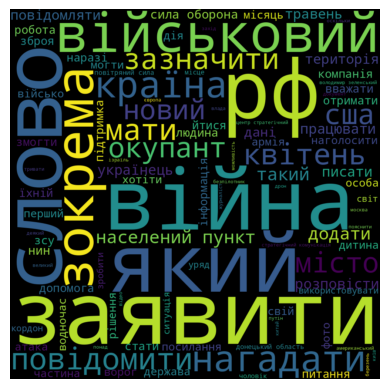

In [196]:
wc = WordCloud(background_color="black", 
               max_words=100,
               max_font_size=256,
               random_state=0, 
               width=1000, 
               height=1000)
wc.generate(' '.join(df['clean_text']))

plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.show()

In [ ]:
text_tokens = [txt.split() for txt in df['clean_text']]
texts = ' '.join(df['clean_text'])
texts = texts.split()

In [ ]:
freq_dist = FreqDist(texts)
keywords = [word for word, _ in freq_dist.most_common(10)]

print("Частотные ключевые слова:", keywords)

In [ ]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
    
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = X.toarray()[0]
keyword_indices = tfidf_scores.argsort()[-10:][::-1]
keywords_tfidf = [feature_names[i] for i in keyword_indices]
    
print("Ключевые слова по TF-IDF:", keywords_tfidf)

In [126]:
all_words = []
sub_df = df[df['source_id'] == 11]
for text in sub_df['clean_text']:
    words = text.split()
    all_words.extend(words)

word_counts = Counter(all_words)

length = len(df) * 0.01
common_words = [word for word, count in word_counts.items() if count >= length]

print("Общие слова, которые встречаются в каждом тексте:")
print(common_words)

Общие слова, которые встречаются в каждом тексте:
['informnapalm', 'канал', 'новий', 'який', 'рф', 'війна', 'https', 'відео', 'дрон', 'нин', 'сила', 'військовий']


In [137]:
# df_main = df
df_main

,id,link,title,text,date,source_id,clean_text
0,137587,https://t.me/s/informnapalm/16817,"Росія до демократії виходила з мечем, а демокр...","Росія до демократії виходила з мечем, а демокр...",2023-05-01 00:00:00,11,демократія виходити меч демократія коровай вол...
1,137588,https://t.me/s/informnapalm/16818,На Брянщині через пошкодження полотна зійшов з...,На Брянщині через пошкодження полотна зійшов з...,2023-05-01 00:00:00,11,брянщина пошкодження полотно зійти рейка потяг...
2,137589,https://t.me/s/informnapalm/16819,Естонський професор права і публіцист українсь...,Естонський професор права і публіцист українсь...,2023-05-01 00:00:00,11,естонський професор право публіцист походження...
3,137590,https://t.me/s/informnapalm/16820,"Друзі, вибачайте, що сьогодні було мало публік...","Друзі, вибачайте, що сьогодні було мало публік...",2023-05-01 00:00:00,11,друг вибачати публікація канал зайнятий заверш...
4,137591,https://t.me/s/informnapalm/16825,⚒ Вугілля Донбасу: квиток в один кінець,⚒ Вугілля Донбасу: квиток в один кінець \n \n...,2023-05-02 00:00:00,11,вугілля донбас квиток кінець окупація частина ...
...,...,...,...,...,...,...,...
47153,184740,https://t.me/s/UkraineNow/52474,+ Миколаївщина,+ Миколаївщина,2024-05-05 00:00:00,8,миколаївщина
47154,184741,https://t.me/s/UkraineNow/52475,Повітряна тривога станом на зараз,Повітряна тривога станом на зараз \n \n За пов...,2024-05-05 00:00:00,8,повітряний тривога стан повідомлення повітряни...
47155,184742,https://t.me/s/UkraineNow/52476,Головні новини за 5 травня:,Головні новини за 5 травня: \n \n ▪️ Вночі вор...,2024-05-05 00:00:00,8,головний новина травень вночі ворог атакувати ...
47156,184743,https://t.me/s/UkraineNow/52477,"Сумська, Миколаївська, Херсонська області - за...","Сумська, Миколаївська, Херсонська області - за...",2024-05-05 00:00:00,8,сумський миколаївський херсонський область заг...


In [135]:
df = df[(df['date'] >= '2024-04-01 00:00:00') & (df['date'] < '2024-05-01 00:00:00')]

In [136]:
df

,id,link,title,text,date,source_id,clean_text
18361,155948,https://t.me/s/informnapalm/21137,Міжнародна розвідувальна спільнота InformNapal...,Міжнародна розвідувальна спільнота InformNapal...,2024-04-01 00:00:00,11,міжнародний розвідувальний спільнота вітати ст...
18362,155949,https://t.me/s/informnapalm/21138,Сьогодні на території тимчасово існуючої РФ од...,Сьогодні на території тимчасово існуючої РФ од...,2024-04-01 00:00:00,11,територія тимчасово існуючий рф одразу завод о...
18363,155950,https://t.me/s/informnapalm/21140,"1 квітня - День визволення Бучі, Ворзеля та Бо...","1 квітня - День визволення Бучі, Ворзеля та Бо...",2024-04-01 00:00:00,11,квітень визволення буча ворзель бородянка нага...
18364,155951,https://t.me/s/informnapalm/21141,"Друзі, раз на добу нагадуємо, що триває цей з...","Друзі, раз на добу нагадуємо, що триває цей з...",2024-04-01 00:00:00,11,друг доба нагадувати тривати збір нагадувати п...
18365,155952,https://t.me/s/informnapalm/21142,1 квітня 2024 року воїнами зенітної ракетної О...,1 квітня 2024 року воїнами зенітної ракетної О...,2024-04-01 00:00:00,11,квітень воїн зенітний ракетний одеський бригад...
...,...,...,...,...,...,...,...
46773,184360,https://t.me/s/UkraineNow/52213,Спецтрибунал для російського диктатора путіна ...,Спецтрибунал для російського диктатора путіна ...,2024-04-30 00:00:00,8,спецтрибунал диктатор путін владний верхівка с...
46774,184361,https://t.me/s/UkraineNow/52214,🇳🇴 Норвегія виділяє ще $600 млн на підтримку...,🇳🇴 Норвегія виділяє ще $600 млн на підтримку...,2024-04-30 00:00:00,8,норвегія виділяти млн підтримка більший частин...
46775,184362,https://t.me/s/UkraineNow/52215,Головні новини за 30 квітня:,Головні новини за 30 квітня: \n \n ▪️ російськ...,2024-04-30 00:00:00,8,головний новина квітень загарбник вдарити каба...
46776,184363,https://t.me/s/UkraineNow/52216,❗️ Вибухи в Одесі,❗️ Вибухи в Одесі \n \n Перебувайте в укриттях...,2024-04-30 00:00:00,8,вибух одеса перебувати укриття загроза балісти...


### Topic modeling

In [197]:
text_tokens = [txt.split() for txt in df['clean_text']]

In [198]:
bigram = Phrases(text_tokens, min_count=5, threshold=10)
bigram_phraser = Phraser(bigram)

bigram_text = [bigram_phraser[txt] for txt in text_tokens]

In [199]:
dictionary = corpora.Dictionary(bigram_text)
corpus = [dictionary.doc2bow(txt) for txt in bigram_text]

In [200]:
num_topics = 5
lda_model = gensim.models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics)

In [201]:
lda_model.print_topics()
# lda_model.show_topics(formatted=False)

[(0,
  '0.006*"військовий" + 0.005*"рф" + 0.004*"війна" + 0.003*"сша" + 0.003*"допомога" + 0.003*"заявити" + 0.003*"мати" + 0.002*"українець" + 0.002*"який" + 0.002*"повідомити"'),
 (1,
  '0.004*"країна" + 0.004*"людина" + 0.004*"війна" + 0.004*"заявити" + 0.003*"який" + 0.002*"квітень" + 0.002*"кордон" + 0.002*"дитина" + 0.002*"новий" + 0.002*"слово"'),
 (2,
  '0.004*"сша" + 0.004*"військовий" + 0.004*"ракета" + 0.004*"країна" + 0.003*"заявити" + 0.003*"квітень" + 0.003*"рф" + 0.003*"удар" + 0.003*"допомога" + 0.003*"атака"'),
 (3,
  '0.004*"військовий" + 0.004*"новий" + 0.003*"сша" + 0.003*"країна" + 0.003*"допомога" + 0.003*"компанія" + 0.003*"війна" + 0.002*"мати" + 0.002*"квітень" + 0.002*"підтримка"'),
 (4,
  '0.005*"місто" + 0.004*"удар" + 0.004*"область" + 0.004*"населений_пункт" + 0.004*"ворог" + 0.003*"пошкоджений" + 0.003*"ракета" + 0.003*"будинок" + 0.003*"людина" + 0.003*"повідомити"')]

In [202]:
# remove = ['україна', 'український', 'росія', 'російський']

for idx, topic in lda_model.print_topics(num_words=5):
    print('Topic: {}'.format(idx))
    words = topic.split('"')[1::2]
#     words = [w for w in words if w not in remove]
    print('Words:', words)

Topic: 0
Words: ['військовий', 'рф', 'війна', 'сша', 'допомога']
Topic: 1
Words: ['країна', 'людина', 'війна', 'заявити', 'який']
Topic: 2
Words: ['сша', 'військовий', 'ракета', 'країна', 'заявити']
Topic: 3
Words: ['військовий', 'новий', 'сша', 'країна', 'допомога']
Topic: 4
Words: ['місто', 'удар', 'область', 'населений_пункт', 'ворог']


In [ ]:
# # Generate word clouds for each topic
# for idx, topic in lda_model.show_topics(formatted=False):
#     word_freq = {word: freq for word, freq in topic}
#     wordcloud = WordCloud(background_color='white').generate_from_frequencies(word_freq)
    
#     # Plot word cloud
#     plt.figure(figsize=(8, 6))
#     plt.imshow(wordcloud, interpolation='bilinear')
#     plt.title('Topic {}'.format(idx))
#     plt.axis('off')
#     plt.show()

In [ ]:
# # Plot word frequencies for each topic
# for idx, topic in lda_model.show_topics(formatted=False):
#     word_freq = {word: freq for word, freq in topic}
#     sorted_word_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
#     top_words = sorted_word_freq[:10]  # Select top 10 words
#     words, freqs = zip(*top_words)
    
#     # Plot bar plot
#     plt.figure(figsize=(8, 6))
#     plt.barh(words, freqs, color='skyblue')
#     plt.gca().invert_yaxis()
#     plt.xlabel('Word Frequency')
#     plt.title('Topic {}'.format(idx))
#     plt.show()

In [ ]:
# # Подсчет количества статей для каждой темы
# topic_counts = [0] * num_topics  # Создаем список нулей для каждой темы
# for doc_topics in lda_model.get_document_topics(corpus):
#     for topic, _ in doc_topics:
#         topic_counts[topic] += 1

# # Визуализация количества статей для каждой темы
# plt.figure(figsize=(10, 6))
# plt.bar(range(num_topics), topic_counts, color='skyblue')
# plt.xlabel('Topic')
# plt.ylabel('Number of Articles')
# plt.title('Number of Articles per Topic')
# plt.xticks(range(num_topics))
# plt.show()

### Cluster analysis

In [203]:
vectorizer = TfidfVectorizer(max_features=1000)
matrix = vectorizer.fit_transform(df['clean_text'])

In [204]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(matrix)

/home/yaroslav_els/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=5)

In [205]:
_, topic_counts = np.unique(kmeans.labels_, return_counts=True)

In [206]:
feature_names = vectorizer.get_feature_names_out()
top_keywords = []

for cluster_center in kmeans.cluster_centers_:
    top_keyword_idxs = cluster_center.argsort()[-5:][::-1]
    top_keywords.append([feature_names[idx] for idx in top_keyword_idxs])

In [207]:
top_keywords

[['військовий', 'рф', 'центр', 'новий', 'війна'],
 ['сша', 'допомога', 'країна', 'президент', 'війна'],
 ['напрямок', 'сила', 'ракета', 'ворог', 'військо'],
 ['пс', 'тривога', 'загроза', 'повітряний', 'укриття'],
 ['ова', 'людина', 'удар', 'поранений', 'будинок']]

In [208]:
print("Наиболее обсуждаемые темы и их ключевые слова:")
for i, count in enumerate(topic_counts):
    print(f"Тема {i}: {count} статей")
    print("Ключевые слова:", ', '.join(top_keywords[i]))
    print()

Наиболее обсуждаемые темы и их ключевые слова:
Тема 0: 2680 статей
Ключевые слова: військовий, рф, центр, новий, війна

Тема 1: 998 статей
Ключевые слова: сша, допомога, країна, президент, війна

Тема 2: 464 статей
Ключевые слова: напрямок, сила, ракета, ворог, військо

Тема 3: 260 статей
Ключевые слова: пс, тривога, загроза, повітряний, укриття

Тема 4: 674 статей
Ключевые слова: ова, людина, удар, поранений, будинок



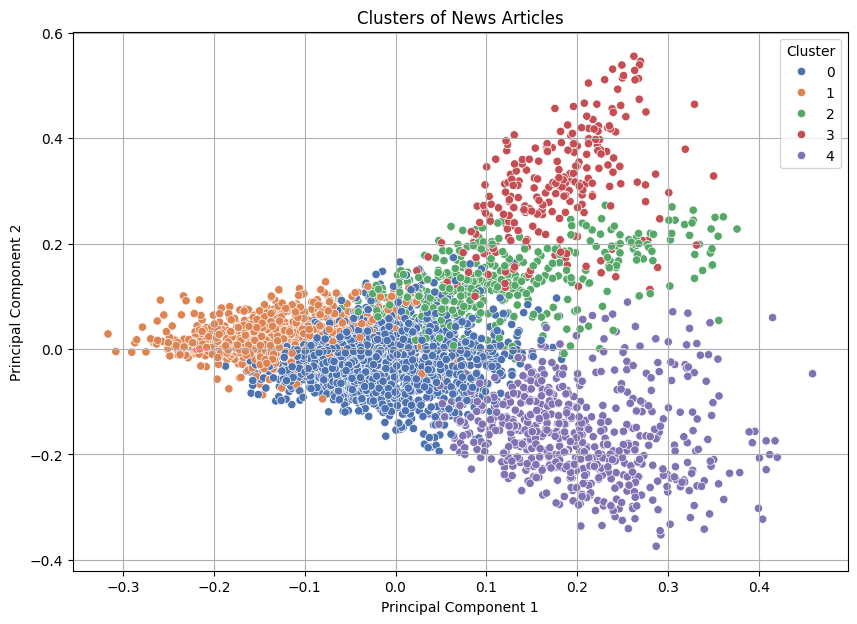

In [209]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(matrix.toarray())

plt.figure(figsize=(10, 7))
sns.scatterplot(x=reduced_features[:, 0], 
                y=reduced_features[:, 1], 
                hue=kmeans.labels_, 
                palette='deep', 
                legend='full')
plt.title('Clusters of News Articles')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [210]:
df['kmean_label'] = kmeans.labels_

In [ ]:
# topics = list(df['kmean_label'].value_counts().index)
# counts = list(df['kmean_label'].value_counts())
# fake_counts_values = [len(df[(df['kmean_label'] == topic) & (df['label'] < 0.5)]) for topic in topics]

# plt.figure(figsize=(6, 4))
# plt.bar(topics, counts, color='#87cefa', label='Всего статей')
# plt.bar(topics, fake_counts_values, color='#ffc87c', label='Фейковые статьи')

# plt.title('Результаты кластерного анализа')
# plt.xlabel('Темы')
# plt.ylabel('Количество статей')
# plt.legend()
# plt.show()

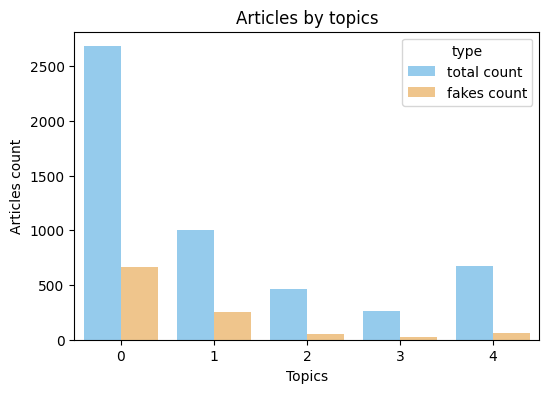

In [211]:
topics = list(df['kmean_label'].value_counts().index)
counts = list(df['kmean_label'].value_counts())
fake_counts_values = [len(df[(df['kmean_label'] == topic) & (df['label'] < 0.5)]) for topic in topics]

df_sns = pd.DataFrame({
    'topic': topics,
    'total count': counts,
    'fakes count': fake_counts_values
})
df_long = df_sns.melt(id_vars='topic', var_name='type', value_name='count')

plt.figure(figsize=(6, 4))
sns.barplot(x='topic', y='count', hue='type', data=df_long, palette=['#87cefa', '#ffc87c'])

plt.title('Articles by topics')
plt.xlabel('Topics')
plt.ylabel('Articles count')
# plt.savefig('my_plot.png')
plt.show()

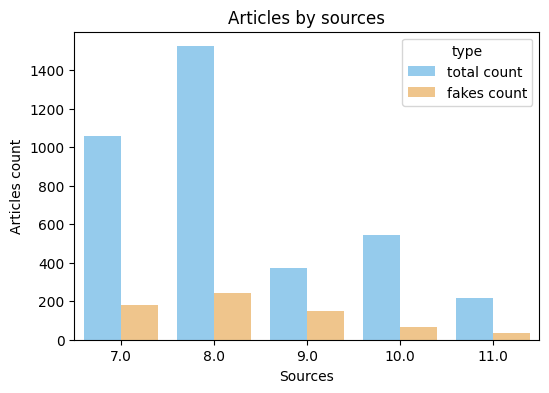

In [212]:
sources = list(df['source_id'].value_counts().index)
counts = list(df['source_id'].value_counts())
fake_counts_values = [len(df[(df['source_id'] == source) & (df['label'] < 0.5)]) for source in sources]

df_sns = pd.DataFrame({
    'source': sources,
    'total count': counts,
    'fakes count': fake_counts_values
})
df_long = df_sns.melt(id_vars='source', var_name='type', value_name='count')

plt.figure(figsize=(6, 4))
sns.barplot(x='source', y='count', hue='type', data=df_long, palette=['#87cefa', '#ffc87c'])

plt.title('Articles by sources')
plt.xlabel('Sources')
plt.ylabel('Articles count')
# plt.savefig('my_plot_2.png')
plt.show()

### Sentiment analysis

In [ ]:
from textblob import TextBlob

# Пример текста для анализа
text = "thw movie was terribly good"

# Создание объекта TextBlob
blob = TextBlob(text)

# Анализ тональности текста
sentiment_score = blob.sentiment.polarity

# Определение эмоциональной окраски
if sentiment_score > 0:
    print("Текст положительный.")
elif sentiment_score < 0:
    print("Текст отрицательный.")
else:
    print("Текст нейтральный.")

### Similarities calculation

In [214]:
def find_similar_texts(sentence, texts):
    vectorizer = TfidfVectorizer()
    vectors = vectorizer.fit_transform([sentence] + texts)
    
    similarity_scores = cosine_similarity(vectors[0], vectors[1:])[0]
    
    ranked_texts = [(text, score) for text, score in zip(texts, similarity_scores)]
    ranked_texts.sort(key=lambda x: x[1], reverse=True)
    
    return ranked_texts

In [215]:
texts = list(df['clean_text'])
sentence = preprocess('Тривога у Києві')

a = find_similar_texts(sentence, texts)

In [216]:
a[:5]

[('кий низка область повітряний тривога загроза застосування балістичний озброєння',
  0.5179026627752549),
 ('травень надвечір ширитися повітряний тривога посилання карта тривог повітряний тривога поширюватись стан карта повітряний тривога виглядати нагадати перший тривога повідомляти повітряний тривога оголошений кий повітряний сила писати київ йти швидкісний ціль писати вчора травень раз оголошувати масштабний тривога причина зліт зауважити писати зв язку вихідний українець святкувати великдень можливий атака нин',
  0.4546589531918997),
 ('травень кий оголосити повітряний тривога передавати посилання карта тривог зяву повітряний сила швидкісний ціль київ повідомити пс повітряний тривога оголосити столиця область детальніше виглядати карта тривог стан побачити фото повітряний тривога кий область скасувати нагадати вчора травень раз оголошувати масштабний тривога причина зліт повідомляти зв язку вихідний українець святкувати великдень можливий атака нин',
  0.42286053004001894),
 ('м

In [47]:
import re

# Пример строки с временем в формате "07:00"
string = "Время: 07:00 утра"

# Используем регулярное выражение для поиска времени в формате "чч:мм"
# pattern = r"\b\d{2}:\d{2}\b"

# Заменяем найденное время на пустую строку
result = re.sub(r'\b\d{2}:\d{2}\b', "", string)

print("Строка без времени:", result)

Строка без времени: Время:  утра


In [176]:
# qwe = df.copy()
qwe.head()

,id,link,title,text,date,source_id,clean_text,clean_title,label,kmean_label
18361,155948,https://t.me/s/informnapalm/21137,Міжнародна розвідувальна спільнота InformNapal...,Міжнародна розвідувальна спільнота InformNapal...,2024-04-01 00:00:00,11,міжнародний розвідувальний спільнота вітати ст...,міжнародна розвідувальна спільнота informnapal...,0.487318,0
18362,155949,https://t.me/s/informnapalm/21138,Сьогодні на території тимчасово існуючої РФ од...,Сьогодні на території тимчасово існуючої РФ од...,2024-04-01 00:00:00,11,територія тимчасово існуючий рф одразу завод о...,сьогодні на території тимчасово існуючої рф од...,0.991001,0
18363,155950,https://t.me/s/informnapalm/21140,"1 квітня - День визволення Бучі, Ворзеля та Бо...","1 квітня - День визволення Бучі, Ворзеля та Бо...",2024-04-01 00:00:00,11,квітень визволення буча ворзель бородянка нага...,квітня день визволення бучі ворзеля та бор...,0.933936,0
18364,155951,https://t.me/s/informnapalm/21141,"Друзі, раз на добу нагадуємо, що триває цей з...","Друзі, раз на добу нагадуємо, що триває цей з...",2024-04-01 00:00:00,11,друг доба нагадувати тривати збір нагадувати п...,друзі раз на добу нагадуємо що триває цей з...,0.990502,0
18365,155952,https://t.me/s/informnapalm/21142,1 квітня 2024 року воїнами зенітної ракетної О...,1 квітня 2024 року воїнами зенітної ракетної О...,2024-04-01 00:00:00,11,квітень воїн зенітний ракетний одеський бригад...,квітня року воїнами зенітної ракетної одеськ...,0.916966,4


In [178]:
conn = sqlite3.connect('../data/news.db')
cursor = conn.cursor()

In [179]:
query = "SELECT * FROM preds"
df = pd.read_sql_query(query, conn)

In [180]:
df

,id,clean_text,label,article_id
0,1,травень пролунати четвертий повітряний тривога...,0.972132,1
1,2,президент володимир зеленський заявити війна п...,0.957578,2
2,3,посол сша бріджит брінк заявити сполучений шта...,0.855462,3
3,4,травень область оголошувати третій повітряний ...,0.990163,4
4,5,розвідка оновити дані кількість сухопутний скл...,0.864014,5
...,...,...,...,...
1354,1355,змінювати підхід кадровий система армія робити...,0.464037,137582
1355,1356,ніч вдарити одеса балістичний ракета відомо за...,0.370792,137583
1356,1357,майор зсу заступник командир третій штурмовий ...,0.862418,137584
1357,1358,норвегія збільшити допомога мільярд норвезький...,0.953872,137585


In [181]:
conn.close()

In [190]:
df

,id,clean_text,label,article_id
0,1,травень пролунати четвертий повітряний тривога...,0.972132,1
1,2,президент володимир зеленський заявити війна п...,0.957578,2
2,3,посол сша бріджит брінк заявити сполучений шта...,0.855462,3
3,4,травень область оголошувати третій повітряний ...,0.990163,4
4,5,розвідка оновити дані кількість сухопутний скл...,0.864014,5
...,...,...,...,...
1354,1355,змінювати підхід кадровий система армія робити...,0.464037,137582
1355,1356,ніч вдарити одеса балістичний ракета відомо за...,0.370792,137583
1356,1357,майор зсу заступник командир третій штурмовий ...,0.862418,137584
1357,1358,норвегія збільшити допомога мільярд норвезький...,0.953872,137585


In [191]:
qwe

,id,link,title,text,date,source_id,clean_text,clean_title,label,kmean_label
18361,155948,https://t.me/s/informnapalm/21137,Міжнародна розвідувальна спільнота InformNapal...,Міжнародна розвідувальна спільнота InformNapal...,2024-04-01 00:00:00,11,міжнародний розвідувальний спільнота вітати ст...,міжнародна розвідувальна спільнота informnapal...,0.487318,0
18362,155949,https://t.me/s/informnapalm/21138,Сьогодні на території тимчасово існуючої РФ од...,Сьогодні на території тимчасово існуючої РФ од...,2024-04-01 00:00:00,11,територія тимчасово існуючий рф одразу завод о...,сьогодні на території тимчасово існуючої рф од...,0.991001,0
18363,155950,https://t.me/s/informnapalm/21140,"1 квітня - День визволення Бучі, Ворзеля та Бо...","1 квітня - День визволення Бучі, Ворзеля та Бо...",2024-04-01 00:00:00,11,квітень визволення буча ворзель бородянка нага...,квітня день визволення бучі ворзеля та бор...,0.933936,0
18364,155951,https://t.me/s/informnapalm/21141,"Друзі, раз на добу нагадуємо, що триває цей з...","Друзі, раз на добу нагадуємо, що триває цей з...",2024-04-01 00:00:00,11,друг доба нагадувати тривати збір нагадувати п...,друзі раз на добу нагадуємо що триває цей з...,0.990502,0
18365,155952,https://t.me/s/informnapalm/21142,1 квітня 2024 року воїнами зенітної ракетної О...,1 квітня 2024 року воїнами зенітної ракетної О...,2024-04-01 00:00:00,11,квітень воїн зенітний ракетний одеський бригад...,квітня року воїнами зенітної ракетної одеськ...,0.916966,4
...,...,...,...,...,...,...,...,...,...,...
46773,184360,https://t.me/s/UkraineNow/52213,Спецтрибунал для російського диктатора путіна ...,Спецтрибунал для російського диктатора путіна ...,2024-04-30 00:00:00,8,спецтрибунал диктатор путін владний верхівка с...,спецтрибунал для російського диктатора путіна ...,0.895180,0
46774,184361,https://t.me/s/UkraineNow/52214,🇳🇴 Норвегія виділяє ще $600 млн на підтримку...,🇳🇴 Норвегія виділяє ще $600 млн на підтримку...,2024-04-30 00:00:00,8,норвегія виділяти млн підтримка більший частин...,норвегія виділяє ще млн на підтримку ук...,0.983024,2
46775,184362,https://t.me/s/UkraineNow/52215,Головні новини за 30 квітня:,Головні новини за 30 квітня: \n \n ▪️ російськ...,2024-04-30 00:00:00,8,головний новина квітень загарбник вдарити каба...,головні новини за квітня,0.882607,2
46776,184363,https://t.me/s/UkraineNow/52216,❗️ Вибухи в Одесі,❗️ Вибухи в Одесі \n \n Перебувайте в укриттях...,2024-04-30 00:00:00,8,вибух одеса перебувати укриття загроза балісти...,вибухи в одесі,0.986225,1


In [192]:
# cols_df1 = ['clean_text', 'label']
# cols_df2 = ['clean_text', 'label']

# # Merge DataFrames based on selected columns
# merged_df = pd.merge(df[cols_df1], qwe[cols_df2], on='key', how='inner')

merged_df = pd.concat([df, qwe], ignore_index=True)

In [194]:
df = merged_df

In [213]:
df

,id,clean_text,label,article_id,link,title,text,date,source_id,clean_title,kmean_label
0,1,травень пролунати четвертий повітряний тривога...,0.972132,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3
1,2,президент володимир зеленський заявити війна п...,0.957578,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1
2,3,посол сша бріджит брінк заявити сполучений шта...,0.855462,3.0,NaN,NaN,NaN,NaN,NaN,NaN,1
3,4,травень область оголошувати третій повітряний ...,0.990163,4.0,NaN,NaN,NaN,NaN,NaN,NaN,3
4,5,розвідка оновити дані кількість сухопутний скл...,0.864014,5.0,NaN,NaN,NaN,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...
5071,184360,спецтрибунал диктатор путін владний верхівка с...,0.895180,NaN,https://t.me/s/UkraineNow/52213,Спецтрибунал для російського диктатора путіна ...,Спецтрибунал для російського диктатора путіна ...,2024-04-30 00:00:00,8.0,спецтрибунал для російського диктатора путіна ...,0
5072,184361,норвегія виділяти млн підтримка більший частин...,0.983024,NaN,https://t.me/s/UkraineNow/52214,🇳🇴 Норвегія виділяє ще $600 млн на підтримку...,🇳🇴 Норвегія виділяє ще $600 млн на підтримку...,2024-04-30 00:00:00,8.0,норвегія виділяє ще млн на підтримку ук...,1
5073,184362,головний новина квітень загарбник вдарити каба...,0.882607,NaN,https://t.me/s/UkraineNow/52215,Головні новини за 30 квітня:,Головні новини за 30 квітня: \n \n ▪️ російськ...,2024-04-30 00:00:00,8.0,головні новини за квітня,1
5074,184363,вибух одеса перебувати укриття загроза балісти...,0.986225,NaN,https://t.me/s/UkraineNow/52216,❗️ Вибухи в Одесі,❗️ Вибухи в Одесі \n \n Перебувайте в укриттях...,2024-04-30 00:00:00,8.0,вибухи в одесі,3


In [227]:
# Sample DataFrame
data = {'A': [1, 2, 3, 1, 2, 3],
        'B': [4, 5, 6, 4, 5, 6],
        'C': [1, 1, 2, 1, 2, 2]}
df = pd.DataFrame(data)

# Get value counts for a specific column in the DataFrame
value_counts_column_A = df['A'].value_counts()
print("Value counts for column 'A':")
print(value_counts_column_A)

Value counts for column 'A':
A
1    2
2    2
3    2
Name: count, dtype: int64


In [232]:
list(value_counts_column_A)

[2, 2, 2]

In [230]:
list(value_counts_column_A.index)

[1, 2, 3]

In [233]:
a = [1, 2, 3]

In [234]:
a+1

TypeError: can only concatenate list (not "int") to list